# Visualizations of MDN

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

## Training the MDN

In [1]:
import torch
from mdn import MixtureDensityNetwork
from mdn_utils import data_preparation, create_dataloaders, train_model
import numpy as np

gas = "O2O2"
batch_size =256
num_epochs = 50

dataset_sizes = np.linspace(1000, 40000, 40, dtype=int)
train_loss_hist_list = []
val_loss_hist_list = []

for idx, nr_datapoints in enumerate(dataset_sizes):
    if gas == "O2O2":
        DATAFILE = "datasets/O2O2_collisions.csv"
    elif gas == "H2H2":
        DATAFILE = "datasets/H2H2_collisions.csv"

    inputs, outputs, train_size, val_size = data_preparation(DATAFILE, nr_samples=nr_datapoints)
    train_loader, val_loader, in_mean, in_std, out_mean, out_std = create_dataloaders(inputs, outputs, train_size, val_size, batch_size=batch_size)

    # Initialize the model
    model = MixtureDensityNetwork(
        input_dim=3,
        output_dim=2,
        num_mixtures=5,
        hidden_dim=128
    )

    # Train the model
    train_loss_hist, val_loss_hist = train_model(model, train_loader, val_loader, in_mean, in_std, out_mean, out_std, num_epochs=num_epochs)
    train_loss_hist_list.append(train_loss_hist)
    val_loss_hist_list.append(val_loss_hist)
    

# # Save model and normalization stats
# if gas == "O2O2":
#     torch.save({
#         'model_state_dict': model.state_dict(),
#         'in_mean': in_mean,
#         'in_std': in_std,
#         'out_mean': out_mean,
#         'out_std': out_std
#     }, "trainedmodels/mdn_O2O2_collision_model.pth")
# elif gas == "H2H2":
#     torch.save({
#         'model_state_dict': model.state_dict(),
#         'in_mean': in_mean,
#         'in_std': in_std,
#         'out_mean': out_mean,
#         'out_std': out_std
#     }, "trainedmodels/mdn_H2H2_collision_model.pth")


# Plot loss
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.plot(range(1, num_epochs + 1), train_loss_hist_list[-1], label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_loss_hist_list[-1], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood Loss')
plt.show()

# Plot final loss for different dataset sizes
plt.figure(figsize=(5, 5))
final_train_losses = [hist[-1] for hist in train_loss_hist_list]
final_val_losses = [hist[-1] for hist in val_loss_hist_list]
plt.plot(dataset_sizes, final_train_losses, label='Final Training Loss')
plt.plot(dataset_sizes, final_val_losses, label='Final Validation Loss')
plt.legend()
plt.xlabel('Dataset Size')
plt.ylabel('Negative Log-Likelihood Loss')

Starting training using 700 training samples and 300 validation samples.


Training MDN: 100%|██████████| 50/50 [00:00<00:00, 60.80epoch/s]


Starting training using 1400 training samples and 600 validation samples.


Training MDN: 100%|██████████| 50/50 [00:01<00:00, 27.03epoch/s]


Starting training using 2100 training samples and 900 validation samples.


...

Starting training using 9100 training samples and 3900 validation samples.


Training MDN: 100%|██████████| 50/50 [00:08<00:00,  5.84epoch/s]


Starting training using 9800 training samples and 4200 validation samples.


Training MDN:  16%|█▌        | 8/50 [00:01<00:07,  5.28epoch/s]


KeyboardInterrupt: 

## Scatterplots of predicted vs true velocities

Finished plot 1
Finished plot 2
Finished plot 3
Finished plot 4


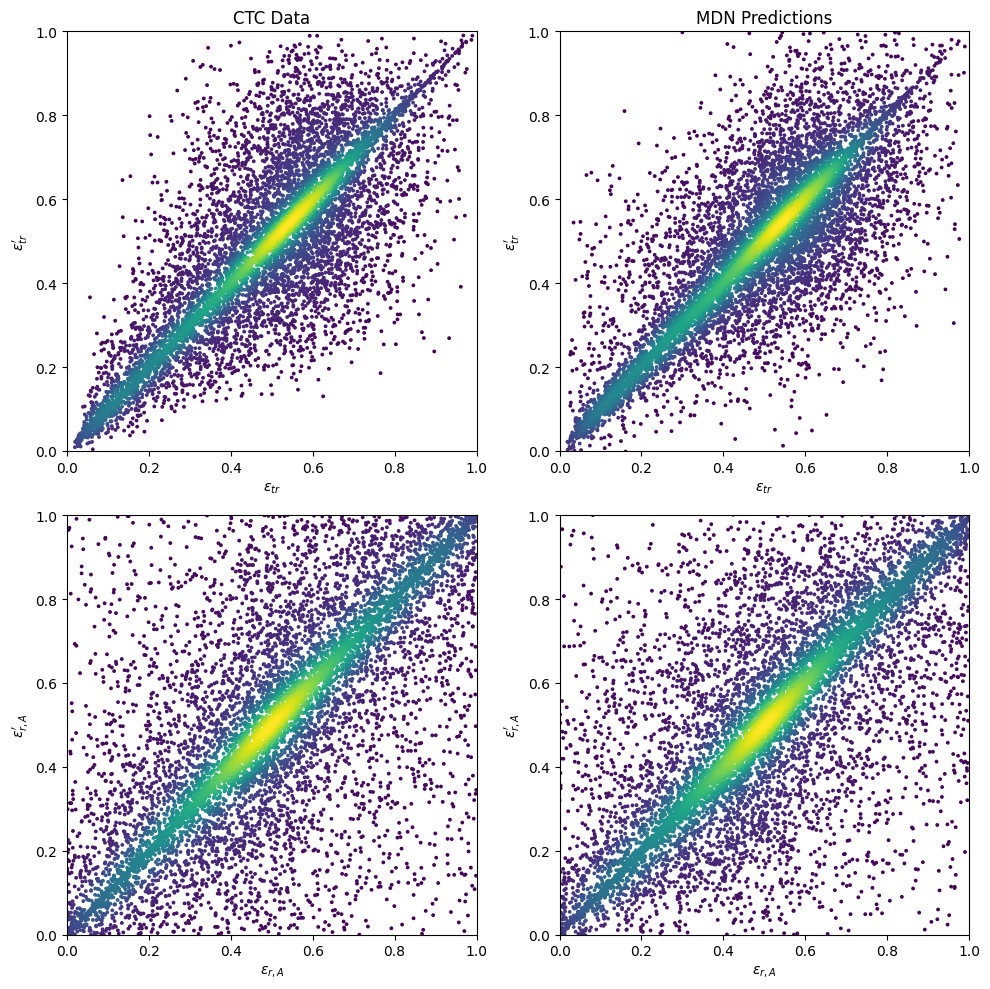

In [5]:
import torch
import numpy as np
from mdn_utils import plot_scattering_comparison
from mdn import MixtureDensityNetwork
from time import time

gas = "H2H2"

# Load model
if gas == "O2O2":
    model_path = "trainedmodels/mdn_O2O2_collision_model.pth"
    DATAFILE = "datasets/O2O2_collisions.csv"
elif gas == "H2H2":
    model_path = "trainedmodels/mdn_H2H2_collision_model.pth"
    DATAFILE = "datasets/H2H2_collisions.csv"

inputs,outputs,_,_ = data_preparation(DATAFILE, nr_samples=10000)
inputdata, outputdata = inputs.numpy(), outputs.numpy()

ckpt = torch.load(model_path, map_location="cpu")
state_dict = ckpt.get("model_state_dict", ckpt)
K = state_dict["pi_layer.weight"].shape[0]
mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=K
)
mdn_model.load_state_dict(state_dict)

# plot comparison
plot_scattering_comparison(
    np.column_stack((inputdata, outputdata)),
    mdn_model,
    nr_samples = 10000,
    in_mean=ckpt.get("in_mean"),
    in_std=ckpt.get("in_std"),
    out_mean=ckpt.get("out_mean"),
    out_std=ckpt.get("out_std"),
)


## PDF's of the predicted distributions vs the true distributions

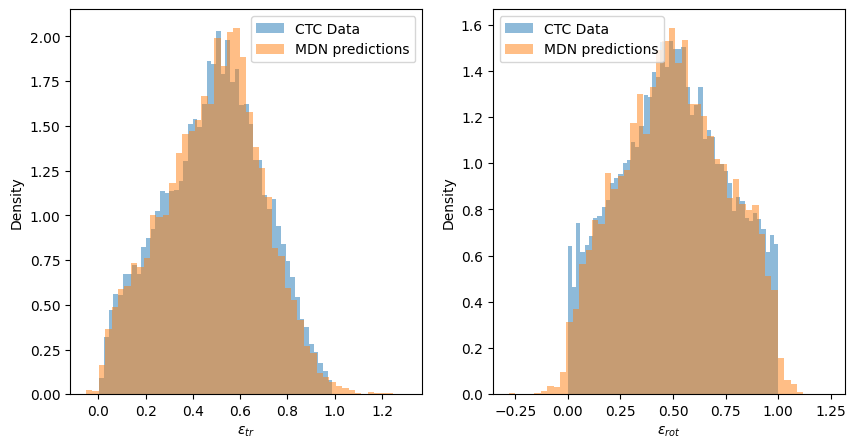

nr samples: 10000
length of true data: 10000


In [19]:
import torch
import numpy as np
from mdn_utils import data_preparation, sample_mdn
from mdn import MixtureDensityNetwork
import matplotlib.pyplot as plt

gas = "H2H2"

# Load model
if gas == "O2O2":
    model_path = "trainedmodels/mdn_O2O2_collision_model.pth"
    DATAFILE = "datasets/O2O2_collisions.csv"
elif gas == "H2H2":
    model_path = "trainedmodels/mdn_H2H2_collision_model.pth"
    DATAFILE = "datasets/H2H2_collisions.csv"

inputs,outputs,_,_ = data_preparation(DATAFILE, nr_samples=10000)
inputdata, outputdata = inputs.numpy(), outputs.numpy()

ckpt = torch.load(model_path, map_location="cpu")
state_dict = ckpt.get("model_state_dict", ckpt)
K = state_dict["pi_layer.weight"].shape[0]
mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=K
)
mdn_model.load_state_dict(state_dict)

# Sample the predicted mixtures
samples = sample_mdn(mdn_model, inputdata=inputdata, in_mean=ckpt.get("in_mean"), in_std=ckpt.get("in_std"), out_mean=ckpt.get("out_mean"), out_std=ckpt.get("out_std"))

# Plot histogram of ctc data and predicted data
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(outputdata[:, 0], bins=50, alpha=0.5, label='CTC Data', density=True)
ax[0].hist(samples[:, 0], bins=50, alpha=0.5, label='MDN predictions', density=True)
ax[0].set_xlabel('$\\epsilon_{tr}$')
ax[0].set_ylabel('Density')
ax[0].legend()

ax[1].hist(outputdata[:, 1], bins=50, alpha=0.5, label='CTC Data', density=True)
ax[1].hist(samples[:, 1], bins=50, alpha=0.5, label='MDN predictions', density=True)
ax[1].set_xlabel('$\\epsilon_{rot}$')
ax[1].set_ylabel('Density')
ax[1].legend()
plt.show()

print("nr samples:", samples.shape[0])
print("length of true data:", outputdata.shape[0])

## Kullback-Leibler Divergence

Total translational Kullback-Leibler divergence: 0.002452240870738233
Total rotational Kullback-Leibler divergence: 0.0030613150681243115


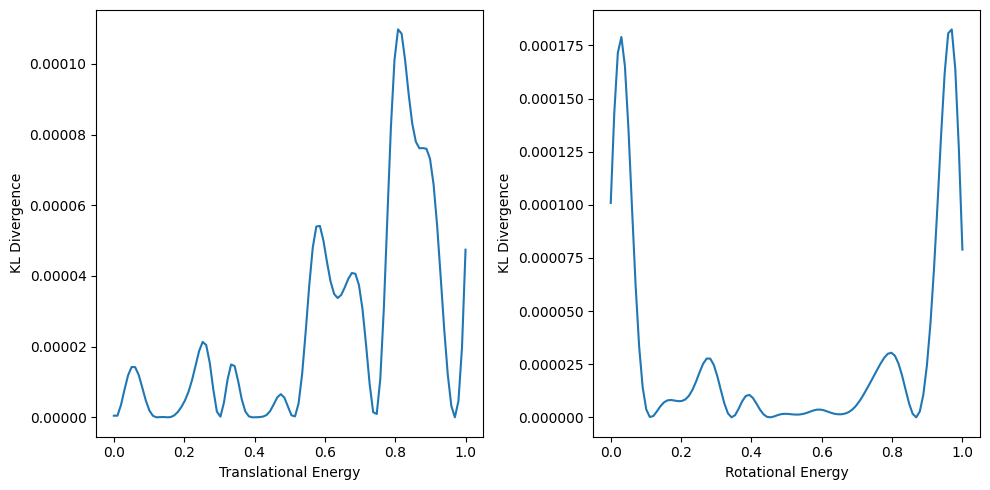

In [18]:
# Compute KL divergence for both models
from scipy.special import kl_div
from scipy.stats import gaussian_kde
from mdn_utils import sample_mdn, data_preparation
import matplotlib.pyplot as plt

gas = "H2H2"
nr_datapoints = 10000

# Load model
if gas == "O2O2":
    model_path = "trainedmodels/mdn_O2O2_collision_model.pth"
    DATAFILE = "datasets/O2O2_collisions.csv"
elif gas == "H2H2":
    model_path = "trainedmodels/mdn_H2H2_collision_model.pth"
    DATAFILE = "datasets/H2H2_collisions.csv"

inputs,outputs,_,_ = data_preparation(DATAFILE, nr_samples=10000)
inputdata, outputdata = inputs.numpy(), outputs.numpy()

ckpt = torch.load(model_path, map_location="cpu")
state_dict = ckpt.get("model_state_dict", ckpt)
K = state_dict["pi_layer.weight"].shape[0]
mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=K
)
mdn_model.load_state_dict(state_dict)
samples = sample_mdn(mdn_model, inputdata[:nr_datapoints], ckpt.get("in_mean"), ckpt.get("in_std"), ckpt.get("out_mean"), ckpt.get("out_std"))
# First compute discrete probability distributions for the true data and the model predictions
grid = np.linspace(0, 1, 100)
ptr_true = gaussian_kde(outputdata[:nr_datapoints, 0].T)(grid)
ptr_model = gaussian_kde(samples[:, 0].T)(grid)
prot_true = gaussian_kde(outputdata[:nr_datapoints, 1].T)(grid)
prot_model = gaussian_kde(samples[:,1].T)(grid)

# Normalize the distributions
ptr_true /= np.sum(ptr_true)
ptr_model /= np.sum(ptr_model)
prot_true /= np.sum(prot_true)
prot_model /= np.sum(prot_model)

# Now compute the KL divergence
kl_div_tr = kl_div(ptr_true, ptr_model)
kl_div_rot = kl_div(prot_true, prot_model)
print(f"Total translational Kullback-Leibler divergence: {kl_div_tr.sum()}")
print(f"Total rotational Kullback-Leibler divergence: {kl_div_rot.sum()}")

# Plot Kl divergence along the grid
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(grid, kl_div_tr, label='KL Divergence (Translational)')
ax[0].set_xlabel('Translational Energy')
ax[0].set_ylabel('KL Divergence')
ax[1].plot(grid, kl_div_rot, label='KL Divergence (Rotational)')
ax[1].set_xlabel('Rotational Energy')
ax[1].set_ylabel('KL Divergence')
plt.tight_layout()
plt.show()